<a href="https://colab.research.google.com/github/Ayushjain270/100-Days-of-Deep-Learning-/blob/main/zero_initializaiton(tanh_and_Relu).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_moons
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from mlxtend.plotting import plot_decision_regions

In [11]:
X , y = make_moons(100 , noise = 0.2 , random_state =42)

In [21]:
y

array([1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1])

<Axes: >

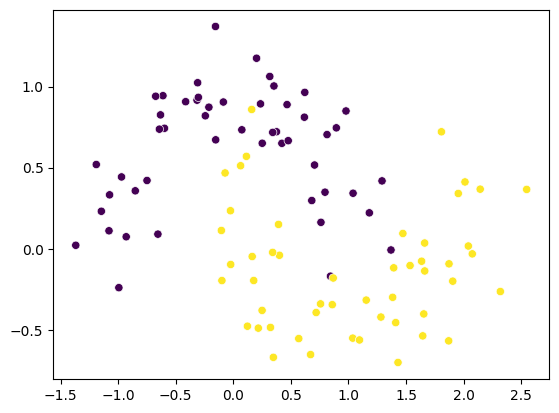

In [12]:
sns.scatterplot(x= X[:,0] , y = X[:,1] , c =y)

In [24]:
model= Sequential()
model.add(Dense(2 , input_dim=2 , activation = "relu"))
model.add(Dense(1 , activation = "sigmoid"))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.get_weights()# these are the intial weights that are set by the keras

[array([[-0.68659   , -1.0979989 ],
        [ 1.2141966 , -0.25120664]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[1.2320231],
        [1.1026503]], dtype=float32),
 array([0.], dtype=float32)]

In [28]:
intial_weights = model.get_weights()

In [40]:
intial_weights[0] = np.zeros(model.get_weights()[0].shape)
intial_weights[1] = np.zeros(model.get_weights()[1].shape)
intial_weights[2] = np.zeros(model.get_weights()[2].shape)
intial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [41]:
intial_weights # we have made all the intial weights zero now we will train the model

[array([[0., 0.],
        [0., 0.]]),
 array([0., 0.]),
 array([[0.],
        [0.]]),
 array([0.])]

In [42]:
model.set_weights(intial_weights)

In [44]:
model.get_weights()# we have made all the intial weights zero now we will train the model

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [45]:
model.compile(optimizer="adam" , metrics = ["accuracy"] , loss= "binary_crossentropy")

In [47]:
history = model.fit(X , y  ,epochs =100 ,validation_split =0.2 )

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - accuracy: 0.5250 - loss: 0.6932 - val_accuracy: 0.4000 - val_loss: 0.6933
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5250 - loss: 0.6931 - val_accuracy: 0.4000 - val_loss: 0.6933
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5250 - loss: 0.6931 - val_accuracy: 0.4000 - val_loss: 0.6934
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5250 - loss: 0.6931 - val_accuracy: 0.4000 - val_loss: 0.6934
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5250 - loss: 0.6931 - val_accuracy: 0.4000 - val_loss: 0.6935
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5250 - loss: 0.6931 - val_accuracy: 0.4000 - val_loss: 0.6936
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5250 - loss: 0.6931 - val_accuracy: 0.4000 - val_loss: 0.6936
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5250 - loss: 0.6930 - val_accuracy: 0.4000 - val_loss

In [49]:
model.get_weights() # after training the model .. is what we get there is no updation in the weights

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([-0.04800523], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


<Axes: >

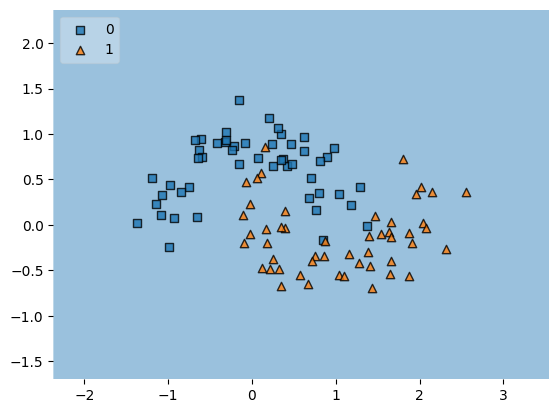

In [50]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

this model working terribely

In [53]:
#you can do by changing Relu to tanh the ans will be same
# this all is happening because we are taking weights zero and after the submission and putting
# in teh activation function like relu or tanh ... it make the output zero ..but the output in
# sigmoid will be different